In [38]:
import pandas as pd
from itertools import combinations
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt



In [39]:
#Loading in the roads data file
df1 = pd.read_csv('./data/_roads3.csv')

#Filtering on the N1 and N2 roads
roads = ['N1', 'N2'] + [f'N{i}' for i in range(100, 300)]
dfN = df1[df1['road'].isin(roads)]


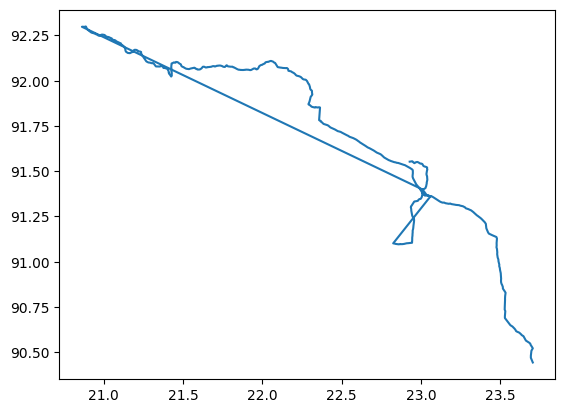

In [40]:
temp_road = ['N1', 'N104', "Z1031"]
temp_df = df1[df1["road"].isin(temp_road)]
plt.plot(temp_df['lat'], temp_df['lon'])
plt.show()


In [41]:
roads

['N1',
 'N2',
 'N100',
 'N101',
 'N102',
 'N103',
 'N104',
 'N105',
 'N106',
 'N107',
 'N108',
 'N109',
 'N110',
 'N111',
 'N112',
 'N113',
 'N114',
 'N115',
 'N116',
 'N117',
 'N118',
 'N119',
 'N120',
 'N121',
 'N122',
 'N123',
 'N124',
 'N125',
 'N126',
 'N127',
 'N128',
 'N129',
 'N130',
 'N131',
 'N132',
 'N133',
 'N134',
 'N135',
 'N136',
 'N137',
 'N138',
 'N139',
 'N140',
 'N141',
 'N142',
 'N143',
 'N144',
 'N145',
 'N146',
 'N147',
 'N148',
 'N149',
 'N150',
 'N151',
 'N152',
 'N153',
 'N154',
 'N155',
 'N156',
 'N157',
 'N158',
 'N159',
 'N160',
 'N161',
 'N162',
 'N163',
 'N164',
 'N165',
 'N166',
 'N167',
 'N168',
 'N169',
 'N170',
 'N171',
 'N172',
 'N173',
 'N174',
 'N175',
 'N176',
 'N177',
 'N178',
 'N179',
 'N180',
 'N181',
 'N182',
 'N183',
 'N184',
 'N185',
 'N186',
 'N187',
 'N188',
 'N189',
 'N190',
 'N191',
 'N192',
 'N193',
 'N194',
 'N195',
 'N196',
 'N197',
 'N198',
 'N199',
 'N200',
 'N201',
 'N202',
 'N203',
 'N204',
 'N205',
 'N206',
 'N207',
 'N208',
 'N20

In [42]:
#Creating the source and sink for the new data frame, based on the minimal and maximal chainage
source_rows = dfN.loc[dfN.groupby('road')['chainage'].idxmin()]
sink_rows = dfN.loc[dfN.groupby('road')['chainage'].idxmax()]

df_proc = (
    pd.concat([source_rows, sink_rows])
    .drop_duplicates(subset=['road', 'chainage', 'lrp'])
    .sort_values(['road', 'chainage'])
    .reset_index(drop=True)
)

In [43]:
#Calculate the total lenght of a road based on it's chainage
df_proc['total_length'] = df_proc.groupby('road')['chainage'].transform('max')
#Filter out roads that have a length smaller then 25 km
df_filtered = (df_proc[df_proc['total_length'] > 25]).copy()
print(df_filtered.size + df_filtered.size)


324


In [44]:
#Adjust dataframe for the resulting dataset
df_filtered['model_type'] = 'sourcesink'
df_filtered['length'] = 0
df_filtered['condition'] = ''

df_filtered = df_filtered[['road', 'lrp', 'model_type', 'name', 'lat', 'lon', 'length', 'condition', 'chainage']]
df_filtered.rename(columns={'lrp': 'id'}, inplace=True)
df_filtered[df_filtered["model_type"] == "sourcesink"]


,road,id,model_type,name,lat,lon,length,condition,chainage
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,,0.000
1,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,,462.254
4,N102,LRPS,sourcesink,Start of road from N1 Mainamati,23.478972,91.118194,0,,0.000
5,N102,LRPE,sourcesink,Meet with N 2 at Sanail,24.050611,91.114667,0,,82.682
8,N104,LRPS,sourcesink,Intersection with Z1031,23.009667,91.399416,0,,0.000
9,N104,LRPE,sourcesink,Meet with Z1441& Z1405 at Sonapur.,22.825749,91.101444,0,,49.630
10,N105,LRPS,sourcesink,"Starts of road from N1,Dhaka teknaf road at Ma...",23.690416,90.546611,0,,0.000
11,N105,LRP048,sourcesink,"B.Bridge 83 km,Tangail 60 km / End of Road In...",23.989527,90.358222,0,,48.870
12,N106,LRPS,sourcesink,Start of Road from Oxygen More,22.393555,91.821583,0,,0.000
13,N106,LRPE,sourcesink,The road ends Infront of DC Bunglow,22.648527,92.201833,0,,66.850


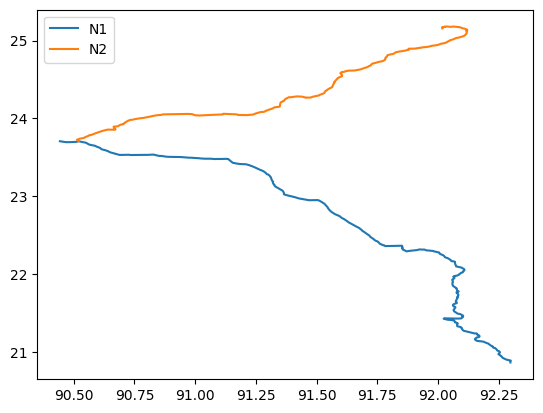

In [45]:
# Visual inspection of N1 and N2
df_plot = dfN[dfN['road'].isin(['N1', 'N2'])]

for road, data in df_plot.groupby('road'):
    plt.plot(data['lon'], data['lat'], label=road)

plt.legend()
plt.show()

In [46]:
#Function to calculate distances between locations on longitude and latitude, based on Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    return R * c

In [47]:
df_n1 = dfN[dfN['road'] == 'N1'].copy()
df_n2 = dfN[dfN['road'] == 'N2'].copy()
#Make dataframe with every possible combination of points on N1 and N2
df_cross = df_n1.merge(df_n2, how='cross', suffixes=('_n1', '_n2'))

#Calculate the distances between every point between N1 and N2
df_cross['distance'] = haversine(
    df_cross['lat_n1'],
    df_cross['lon_n1'],
    df_cross['lat_n2'],
    df_cross['lon_n2']
)
#Find intersections by setting a threshold distance of 0.05 km
intersections = df_cross[df_cross['distance'] < 0.05]

#Dataframe showing the intersections of N1 and N2 based on the threshold distance of 0.05 km
intersections[['road_n1','chainage_n1','lrp_n1',
               'road_n2','chainage_n2','lrp_n2',
               'distance']]



,road_n1,chainage_n1,lrp_n1,road_n2,chainage_n2,lrp_n2,distance
15062,N1,8.763,LRP009a,N2,0.0,LRPS,0.020374


In [48]:
#Find all possible combinations of roads
roads = df_filtered['road'].unique()
road_pairs = list(combinations(roads, 2))


In [49]:
#Find all intersections by checking the distances of every point between two roads, and calculate if this
#distance is smaller then the threshold of 0.05 km
all_intersections = []

for r1, r2 in road_pairs:

    df_r1 = dfN[dfN['road'] == r1]
    df_r2 = dfN[dfN['road'] == r2]

    df_cross = df_r1.merge(df_r2, how='cross', suffixes=('_1', '_2'))

    df_cross['distance'] = haversine(
        df_cross['lat_1'],
        df_cross['lon_1'],
        df_cross['lat_2'],
        df_cross['lon_2']
    )

    inter = df_cross[df_cross['distance'] < 0.05]

    all_intersections.append(inter)

intersections = pd.concat(all_intersections, ignore_index=True)



In [50]:
#Group points that are based on the same intersection
intersection_groups = {}
group_id = 0

for _, row in intersections.iterrows():

    a = (row['road_1'], row['lrp_1'])
    b = (row['road_2'], row['lrp_2'])

    if a in intersection_groups:
        intersection_groups[b] = intersection_groups[a]

    elif b in intersection_groups:
        intersection_groups[a] = intersection_groups[b]

    else:
        intersection_groups[a] = group_id
        intersection_groups[b] = group_id
        group_id += 1

In [51]:
#Extract the intersection point from side 1 of each road pair and of side 2
df_i1 = intersections[['road_1','lrp_1','chainage_1']].rename(columns={
    'road_1':'road',
    'lrp_1':'lrp',
    'chainage_1':'chainage'
})
df_i2 = intersections[['road_2','lrp_2','chainage_2']].rename(columns={
    'road_2':'road',
    'lrp_2':'lrp',
    'chainage_2':'chainage'
})
#Combine both sides into one intersection-node table
df_intersections = pd.concat([df_i1, df_i2])

#Merge with the original road dataset
df_intersections = df_intersections.merge(
    dfN,
    on=['road','lrp','chainage'],
    how='left'
)

#Adjust dataframe for the resulting dataset
df_intersections['model_type'] = 'intersection'
df_intersections['length'] = 0
df_intersections['condition'] = ''

#Map each node to its intersection group
df_intersections['intersection_group'] = df_intersections.apply(
    lambda r: intersection_groups.get((r['road'], r['lrp']), None),
    axis=1
)
#Finalise the dataframe
df_intersections = df_intersections[['road','lrp','model_type','name','lat','lon','length','condition','chainage', 'intersection_group']]
df_intersections = df_intersections.rename(columns={'lrp':'id'})



In [52]:
# Group nearby points within each road and assign them a shared ID
def sync_geographical_ids(df, threshold=0.05):
    final_groups = []

    #Group dataframe per road
    for road, group in df.groupby('road'):
        #Reset reference locations for the current road
        master_locations = []
        synced_ids = []

        #Work on a copy to avoid modifying the grouped slice directly
        group = group.copy()

        for index, row in group.iterrows():
            current_lat = row['lat']
            current_lon = row['lon']
            current_id = row['id']

            match_found = False
            #Compare current point to previously stored reference locations
            for master_lat, master_lon, master_id in master_locations:
                distance = haversine(current_lat, current_lon, master_lat, master_lon)

                if distance <= threshold:
                    #Reuse the existing ID if the point matches a known location
                    synced_ids.append(master_id)
                    match_found = True
                    break

            if not match_found:
                #No match, new unique location for this road
                master_locations.append((current_lat, current_lon, current_id))
                synced_ids.append(current_id)

        #Replace original IDs with synchronized IDs
        group['id'] = synced_ids

        #Remove duplicates
        group = group.drop_duplicates('id')

        final_groups.append(group)

    #Combine all processed roads into one dataframe
    return pd.concat(final_groups).reset_index(drop=True)

In [53]:
#Use the sync_geographical_ids on the dataframe
df_unique = sync_geographical_ids(df_intersections)

In [54]:
#Combine the filtered road points and the unique nodes into one dataframe and sort by road and chainage
df_final = pd.concat([df_filtered, df_unique], ignore_index=True)
df_final = df_final.sort_values(['road', 'chainage']).reset_index(drop=True)

In [55]:
#Make a function that deletes sourcesinks of sideroads of N1 and N2 that are on N1 and N2
def remove_overlapping_sourcesinks(df, threshold=0.05):
    indices_to_drop = []

    for road, group in df.groupby('road'):
        #Sort points within the road for more consistent pairwise comparison
        group = group.sort_values('chainage')
        indices = group.index.tolist()
        #Compare each node with all following nodes on the same road
        for i in range(len(indices)):
            for j in range(i + 1, len(indices)):
                idx_a = indices[i]
                idx_b = indices[j]

                dist = haversine(
                    df.at[idx_a, 'lat'], df.at[idx_a, 'lon'],
                    df.at[idx_b, 'lat'], df.at[idx_b, 'lon']
                )
                #If two nodes overlap geographically, one should be deleted
                if dist <= threshold:
                    type_a = df.at[idx_a, 'model_type']
                    type_b = df.at[idx_b, 'model_type']

                    #Delete sourcesink if the other point is of a different type
                    if type_a == 'sourcesink' and type_b != 'sourcesink':
                        indices_to_drop.append(idx_a)
                    elif type_b == 'sourcesink' and type_a != 'sourcesink':
                        indices_to_drop.append(idx_b)
                    #If both points are , delete the second one
                    elif type_a == 'sourcesink' and type_b == 'sourcesink':
                        indices_to_drop.append(idx_a)

    #Remove duplicates from the dataframe
    df_cleaned = df.drop(index=list(set(indices_to_drop))).reset_index(drop=True)
    return df_cleaned

#Final dataframe whereby the function is used
df_final = remove_overlapping_sourcesinks(df_final)
df_final[df_final["model_type"] == "sourcesink"]


,road,id,model_type,name,lat,lon,length,condition,chainage,intersection_group
0,N1,LRPS,sourcesink,Start of Road after Jatrabari Flyover infront...,23.706028,90.443333,0,,0.000,NaN
5,N1,LRPE,sourcesink,"End of Road at Shapla Chattar ,Teknaf Meet wit...",20.862917,92.298083,0,,462.254,NaN
8,N104,LRPS,sourcesink,Intersection with Z1031,23.009667,91.399416,0,,0.000,NaN
10,N104,LRPE,sourcesink,Meet with Z1441& Z1405 at Sonapur.,22.825749,91.101444,0,,49.630,NaN
13,N105,LRP048,sourcesink,"B.Bridge 83 km,Tangail 60 km / End of Road In...",23.989527,90.358222,0,,48.870,NaN
14,N106,LRPS,sourcesink,Start of Road from Oxygen More,22.393555,91.821583,0,,0.000,NaN
15,N106,LRPE,sourcesink,The road ends Infront of DC Bunglow,22.648527,92.201833,0,,66.850,NaN
25,N2,LRPE,sourcesink,Road End at Jaflong.,25.157056,92.017638,0,,286.516,NaN


In [56]:
#Loading in the Bridges data
df_BMMS = pd.read_excel('./data/BMMS_overview.xlsx')

#Selecting the columns that we need
cols = [
    "road",
    "name",
    "LRPName",
    "length",
    "chainage",
    "lat",
    "lon",
    "condition",
]

bridges_BMMS = df_BMMS[cols].copy()

#Filter the dataframe on the roads that are needed and make it uniform
roads = df_filtered['road'].unique()
bridges_BMMS = bridges_BMMS[bridges_BMMS['road'].isin(roads)]
bridges_BMMS['name_clean'] = bridges_BMMS['name'].astype(str).str.replace(' ', '').str.upper()

In [57]:
#Dropping duplicates
df_unique = bridges_BMMS.drop_duplicates(
    subset=['chainage','lat','lon'],
    keep='first'
).reset_index(drop=True)

#Filtering on bridges only
df_unique['model_type'] = 'bridge'

#Filter the dataframe on what is needed
df_bridges = df_unique[['road','LRPName','model_type','name','lat','lon','length','condition','chainage']]
df_bridges = df_bridges.rename(columns={'LRPName':'id'})

#Append bridges to the main dataframe
df_final = pd.concat([df_final, df_bridges], ignore_index=True)

#Sort dataframe on road and chainage
df_final = df_final.sort_values(['road','chainage']).reset_index(drop=True)

#Remove duplicate structures on the same road based on a cleaned name prefix
df_final = (
    df_final
    .assign(
        prefix=(
            df_final["name"]
            .str.replace('.', '')
            .str.lower()
            .str.strip()
            .str.extract(r"^([^(]+)", expand=False)
        )
    )
    .drop_duplicates(subset=['road','prefix'], keep='first')
    .drop(columns="prefix")
)

In [58]:
#Insert link records between consecutive points/nodes along each road
final_df_with_links = []

for road, road_df in df_final.groupby('road'):
    #Sort nodes in travel order along the road
    road_df = road_df.sort_values('chainage').reset_index(drop=True)

    for j in range(len(road_df)):
        row = road_df.iloc[j]

        #Keep the first node
        if j == 0:
            final_df_with_links.append(row)
            continue

        prev = road_df.iloc[j-1]

        #Compute midpoint coordinates for the link
        lat_link = (row['lat'] + prev['lat']) / 2
        lon_link = (row['lon'] + prev['lon']) / 2

        #Compute link length from the chainage difference
        link_length = (row['chainage'] - prev['chainage']) * 1000

        #Create a link record between the previous and current node
        link = {
            'road': road,
            'id': None,
            'model_type': 'link',
            'name': 'Link',
            'lat': lat_link,
            'lon': lon_link,
            'length': link_length,
            'condition': 'NaN',
            'chainage': (row['chainage'] + prev['chainage']) / 2
        }

        final_df_with_links.append(pd.Series(link))
        final_df_with_links.append(row)

#Combine all nodes and links into one dataframe
final_df_with_links = pd.DataFrame(final_df_with_links).reset_index(drop=True)

In [59]:
#Assumption on the length of an intersection, based on the given data
intersection_length = 20

#Add intersection length to the dataframe
final_df_with_links.loc[
    final_df_with_links['model_type'] == 'intersection',
    'length'
] = intersection_length

In [60]:
#Adjust link lengths by subtracting half the length of the adjacent points/nodes
for i in range(1, len(final_df_with_links)-1):

    #Only update rows that represent links
    if final_df_with_links.loc[i, 'model_type'] == 'link':
        #Get the lengths of the previous and next point/node
        prev_len = final_df_with_links.loc[i-1, 'length']
        next_len = final_df_with_links.loc[i+1, 'length']

        #Correct the link length to avoid double counting neighboring node/point lengths
        final_df_with_links.loc[i, 'length'] = (
            final_df_with_links.loc[i, 'length']
            - prev_len/2
            - next_len/2
        )

In [61]:
#Assign IDs to each row
final_df_with_links['id'] = 100000 + (final_df_with_links.index + 1)

#Take roads that are intersections
mask = final_df_with_links['model_type'] == 'intersection'

#Assign the same IDs to all rows within the same intersection group
final_df_with_links.loc[mask, 'id'] = (
    final_df_with_links[mask]
    .groupby('intersection_group')['id']
    .transform('first')
)
#Remove the temporary grouping column (not needed anymore)
final_df_with_links.drop('intersection_group', axis=1, inplace=True)


In [62]:
#check if everything is connected:
G = nx.Graph()

for road, group in final_df_with_links.groupby('road'):
    nodes = group['id'].tolist()
    for i in range(len(nodes) - 1):
        G.add_edge(nodes[i], nodes[i+1])

num_components = nx.number_connected_components(G)
print(f"seperate island-networks: {num_components}")

seperate island-networks: 2


In [63]:
#check how big the islands are
components = list(nx.connected_components(G))
for i, c in enumerate(components):
    print(f"Island {i+1} has {len(c)} components.")

#which roads are at which islands?
for i, c in enumerate(components):
    roads_in_component = final_df_with_links[final_df_with_links['id'].isin(c)]['road'].unique()
    print(f"Island {i+1} has roads: {roads_in_component}")

Island 1 has 2709 components.
Island 2 has 203 components.
Island 1 has roads: ['N1' 'N102' 'N104' 'N105' 'N2' 'N204' 'N207' 'N208']
Island 2 has roads: ['N106']


In [64]:
#Identify the nearest N1 or N2 nodes to the start and end of road N106
def get_nearest(point, search_df):
    #Compute distances from the input point to all candidate points and return the minimum distance and the
    #Matching row
    dists = haversine(point['lat'], point['lon'], search_df['lat'], search_df['lon'])
    idx = dists.idxmin()
    return dists[idx], search_df.loc[idx]

#Find the nearest point to N106 for road N1 and N2
n106 = final_df_with_links[final_df_with_links.road == 'N106'].sort_values('chainage')
n1_n2 = final_df_with_links[final_df_with_links.road.isin(['N1', 'N2'])]
d_start, r_start = get_nearest(n106.iloc[0], n1_n2)
d_end, r_end = get_nearest(n106.iloc[-1], n1_n2)

print(f"Start N106: {d_start:.3f} km from {r_start['road']} (Ch {r_start['chainage']})")
print(f"End N106: {d_end:.3f} km from {r_end['road']} (Ch {r_end['chainage']})")

Start N106: 3.315 km from N1 (Ch 236.99099999999999)
End N106: 45.638 km from N1 (Ch 263.2425)


In [65]:
#Make sure that per road we only have one intersection ID and sort on chainage to keep the most
#Logical point (the first one encountered)
final_df_clean = final_df_with_links.sort_values(['road', 'chainage']).drop_duplicates(subset=['road', 'id'], keep='first')

#Update final dataframe
final_df_with_links = final_df_clean.reset_index(drop=True)

final_df_with_links.head(20)
final_df_with_links[final_df_with_links["road"] == "N104"]

,road,id,model_type,name,lat,lon,length,condition,chainage
1358,N104,101359,sourcesink,Intersection with Z1031,23.009667,91.399416,0.000,,0.0000
1359,N104,101360,link,Link,23.009514,91.397782,347.175,NaN,0.1745
1360,N104,101361,bridge,Shasaugtachha culvert,23.009362,91.396149,3.650,A,0.3490
1361,N104,101362,link,Link,23.009332,91.395830,64.825,NaN,0.3830
1362,N104,101363,bridge,S.S.SK ROAD SLAB CULVERT,23.009302,91.395512,2.700,B,0.4170
...,...,...,...,...,...,...,...,...,...
1438,N104,101439,bridge,UTTOR SONAPUR SLAB CULVERT,22.836504,91.099864,2.000,B,48.4170
1439,N104,101440,link,Link,22.834202,91.100266,519.500,NaN,48.6780
1440,N104,101441,bridge,SONAMIPUR BOX CULVERT,22.831900,91.100669,3.000,A,48.9390
1441,N104,101442,link,Link,22.828825,91.101057,689.500,NaN,49.2845


In [66]:
#Create intersection between N106 and N1
target_n1_chainage = 236.991
n106_start_chainage = 0.0

#Find the row in N1
n1_mask = (final_df_with_links['road'] == 'N1') & (final_df_with_links['chainage'].between(target_n1_chainage - 0.01, target_n1_chainage + 0.01))

if n1_mask.any():
    #Get ID from N1
    n1_id = final_df_with_links.loc[n1_mask, 'id'].values[0]

    #Put model type to intersection
    final_df_with_links.loc[n1_mask, 'model_type'] = 'intersection'

    #Find starting point from N106
    n106_mask = (final_df_with_links['road'] == 'N106') & (final_df_with_links['chainage'] == n106_start_chainage)

    if n106_mask.any():
        #Make it the same ID
        final_df_with_links.loc[n106_mask, 'id'] = n1_id

        #Make intersection
        final_df_with_links.loc[n106_mask, 'model_type'] = 'intersection'

#Create overview
id_counts = final_df_with_links['id'].value_counts()
shared_ids = id_counts[id_counts > 1].index

intersection_overzicht = final_df_with_links[(final_df_with_links['id'].isin(shared_ids)) & (final_df_with_links['model_type'] == 'intersection')]

#Group
overzicht_tabel = intersection_overzicht.groupby('id').agg({
    'road': lambda x: ' & '.join(sorted(x.unique())),
    'model_type': 'first',
    'name': 'first',
    'chainage': 'first'
}).reset_index()

#Visual check
display(overzicht_tabel[overzicht_tabel['road'].str.contains('N106')])

,id,road,model_type,name,chainage
4,100418,N1 & N106,intersection,Link,236.991


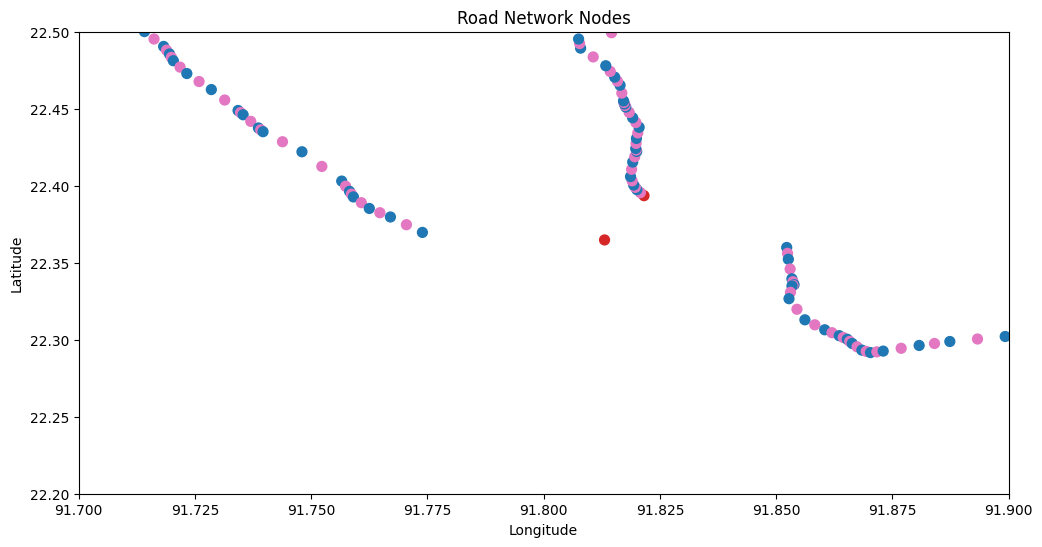

In [83]:
#Visualisation of the road network points/nodes
plt.figure(figsize=(12,6))

colors = final_df_with_links['model_type'].astype('category').cat.codes

plt.scatter(
    final_df_with_links['lon'],
    final_df_with_links['lat'],
    c=colors,
    cmap='tab10',
    s=50
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Road Network Nodes')
plt.xlim(91.7, 91.9)
plt.ylim(22.2, 22.5)
plt.show()

In [68]:
mask = final_df_with_links["model_type"] == "sourcesink"

final_df_with_links["name"] = ""
final_df_with_links.loc[mask, "name"] = "SoSi" + (mask.cumsum()).astype(str)
final_df_with_links.drop('chainage', axis=1, inplace=True)

final_df_with_links = final_df_with_links[['road','id','model_type','condition','name','lat','lon','length']]

In [69]:
final_df_with_links.value_counts('model_type')


model_type
link            1457
bridge          1434
intersection      26
sourcesink         7
Name: count, dtype: int64

In [70]:
final_df_with_links['road'].unique().size

9

In [84]:
final_df_with_links[final_df_with_links["model_type"] == "intersection"]


,road,id,model_type,condition,name,lat,lon,length
4,N1,100005,intersection,NaN,,23.706083,90.521527,20.000
18,N1,100019,intersection,NaN,,23.690416,90.546583,20.000
126,N1,100127,intersection,NaN,,23.478944,91.117722,20.000
236,N1,100237,intersection,NaN,,23.009556,91.381360,20.000
417,N1,100418,intersection,NaN,,22.364795,91.813098,10046.175
1177,N102,100127,intersection,NaN,,23.478972,91.118194,20.000
1357,N102,101358,intersection,NaN,,24.050611,91.114667,20.000
1364,N104,100237,intersection,NaN,,23.009528,91.381444,20.000
1443,N105,100019,intersection,NaN,,23.690416,90.546611,20.000
1457,N105,101458,intersection,NaN,,23.785194,90.568805,20.000


In [80]:
intersect_idx = final_df_with_links["model_type"] == 'intersection'
final_df_with_links.loc[intersect_idx, 'condition'] = "NaN"
final_df_with_links.head(20)

,road,id,model_type,condition,name,lat,lon,length
0,N1,100001,sourcesink,,SoSi1,23.706028,90.443333,0.000
1,N1,100002,link,NaN,,23.702383,90.451097,1794.350
2,N1,100003,bridge,A,,23.698739,90.458861,11.300
3,N1,100004,link,NaN,,23.702411,90.490194,6947.350
4,N1,100005,intersection,NaN,,23.706083,90.521527,20.000
5,N1,100006,link,NaN,,23.705572,90.522371,5.885
6,N1,100007,bridge,A,,23.705060,90.523214,394.230
7,N1,100008,link,NaN,,23.700730,90.529157,1365.885
8,N1,100009,bridge,B,,23.696400,90.535099,8.000
9,N1,100010,link,NaN,,23.695395,90.536337,329.850


In [81]:
#Save final dataframe as CSV
final_df_with_links.to_csv('data/data_intersectionsN1N2.csv')